In [4]:
import pandas as pd

df = pd.read_csv('/Users/wfr5091/code/random-polymers/no_avg_dataset.csv', index_col=0).iloc[:, 1:]
df

,Filename,Frame,Sequence,Z0,Z1,p,Run number
11,Npol_500_Nmon_20_seq_AAABABABBAABBBABAAAA_run_...,0,AAABABABBAABBBABAAAA,-1.366658,0.712638,0.0,0.0
12,Npol_500_Nmon_20_seq_AAABABABBAABBBABAAAA_run_...,0,AAABABABBAABBBABAAAA,-0.181364,0.418596,0.1,0.0
13,Npol_500_Nmon_20_seq_AAABABABBAABBBABAAAA_run_...,0,AAABABABBAABBBABAAAA,1.132397,0.483376,0.2,0.0
14,Npol_500_Nmon_20_seq_AAABABABBAABBBABAAAA_run_...,0,AAABABABBAABBBABAAAA,1.001898,0.763901,0.3,0.0
15,Npol_500_Nmon_20_seq_AAABABABBAABBBABAAAA_run_...,0,AAABABABBAABBBABAAAA,0.466037,-0.282413,0.4,0.0
...,...,...,...,...,...,...,...
17808,Npol_500_Nmon_20_seq_BBBBBBBBAAAAAAAAAAAA_run_...,0,BBBBBBBBAAAAAAAAAAAA,0.965939,-2.687108,0.6,4.0
17809,Npol_500_Nmon_20_seq_BBBBBBBBAAAAAAAAAAAA_run_...,0,BBBBBBBBAAAAAAAAAAAA,1.229532,-1.270968,0.7,4.0
17810,Npol_500_Nmon_20_seq_BBBBBBBBAAAAAAAAAAAA_run_...,0,BBBBBBBBAAAAAAAAAAAA,1.442412,-0.082836,0.8,4.0
17811,Npol_500_Nmon_20_seq_BBBBBBBBAAAAAAAAAAAA_run_...,0,BBBBBBBBAAAAAAAAAAAA,2.607408,0.533102,0.9,4.0


In [49]:
import numpy as np

_, sid = np.unique(df['Sequence'], return_inverse=True)
zp = np.zeros([len(sid), 2])
for s in np.unique(sid):
    zp[s] = np.mean(df.loc[np.logical_and(sid==s, df.loc[:, 'p'] == 0), 'Z0':'Z1'], axis=0)
df['ZP0'] = zp[sid, 0]
df['ZP1'] = zp[sid, 1]

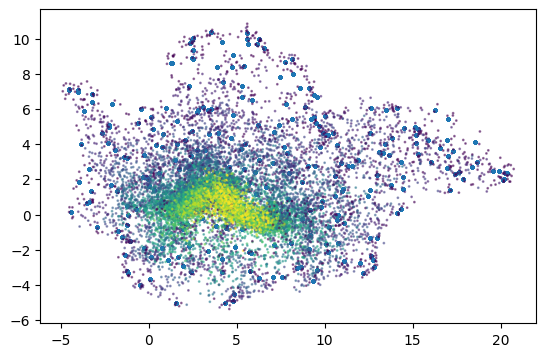

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(df['ZP0'], df['ZP1'], s=4, alpha=0.5)
ax.scatter(df['Z0'], df['Z1'], c=df['p'], s=1, alpha=0.5)
ax.set_aspect('equal')

In [68]:
from sklearn import model_selection, preprocessing
import torch

x = df.loc[:, ['ZP0', 'ZP1', 'p']].values
y = df.loc[:, ['Z0', 'Z1']].values

train_sid, tv_sid = model_selection.train_test_split(np.unique(sid), train_size=0.60, random_state=0)
test_sid, val_sid = model_selection.train_test_split(tv_sid, train_size=0.50, random_state=0)

train_idx = [i for i, s in enumerate(sid) if s in train_sid]
val_idx = [i for i, s in enumerate(sid) if s in val_sid]
test_idx = [i for i, s in enumerate(sid) if s in test_sid]

# scaler = preprocessing.StandardScaler().fit(y[train_idx])
# y = scaler.transform(y)

x_train = torch.tensor(x[train_idx]).float()
y_train = torch.tensor(y[train_idx]).float()

x_valid = torch.tensor(x[val_idx]).float()
y_valid = torch.tensor(y[val_idx]).float()

x_test = torch.tensor(x[test_idx]).float()
y_test = torch.tensor(y[test_idx]).float()

print(x_train.shape, y_train.shape)

torch.Size([8904, 3]) torch.Size([8904, 2])


In [351]:
from torch import nn, optim
import torch.nn.functional as F
import sparsenn

class MultiTaskMSELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        # Mask out the NaN values in the targets
        mask = ~torch.isnan(target)

        # Compute the mean squared error, ignoring NaN values
        mse = F.mse_loss(input[mask], target[mask], reduction='mean')

        return mse
    

input_dim = x_train.shape[1]
hidden_dim = (4, 4, 4, 4, )
hidden_dim = [int(h*1) for h in hidden_dim]
output_dim = y_train.shape[1]

model = sparsenn.RegularizedMLP(input_dim, hidden_dim, output_dim, activation=nn.ELU())
criterion = MultiTaskMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

best_model = (None, np.inf, np.inf)

In [353]:
from copy import deepcopy
import torch.utils

# Training loop
# best_model = (None, np.inf, np.inf)

train_loader = torch.utils.data.DataLoader(list(zip(x_train, y_train)), batch_size=2048, shuffle=True)

lmbda_reg = 1e-3
n_epoch = int(1e3)
model.train()
for epoch in range(n_epoch):
    for x_train_b, y_train_b in train_loader:
        optimizer.zero_grad()
        outputs = model(x_train_b)
        loss = criterion(outputs, y_train_b)
        reg_loss = model.regularization_loss()
        total_loss = loss + lmbda_reg * reg_loss
        total_loss.backward()
        optimizer.step()

    if (epoch+1) % 100 == 0:
        model.eval()
        with torch.no_grad():
            outputs = model(x_valid)
            valid_loss = criterion(outputs, y_valid)
            outputs = model(x_test)
            test_loss = criterion(outputs, y_test)
        if valid_loss < best_model[1]:
            best_model = (deepcopy(model), valid_loss.item(), test_loss.item())
        print(f'Epoch {epoch+1}, RMSE: {np.sqrt(loss.item()):.4f}, L0R: {reg_loss.item():.2f}, ValRMSE: {np.sqrt(valid_loss.item()):.4f}, TestRMSE: {np.sqrt(test_loss.item()):.4f}')
        model.train()

Epoch 100, RMSE: 1.1545, L0R: 64.29, ValRMSE: 1.1548, TestRMSE: 1.3025
Epoch 200, RMSE: 1.0910, L0R: 64.05, ValRMSE: 1.0591, TestRMSE: 1.2610
Epoch 300, RMSE: 1.1178, L0R: 63.53, ValRMSE: 1.0722, TestRMSE: 1.2842
Epoch 400, RMSE: 1.1160, L0R: 63.14, ValRMSE: 1.0665, TestRMSE: 1.2612
Epoch 500, RMSE: 1.1687, L0R: 62.75, ValRMSE: 1.1236, TestRMSE: 1.3459
Epoch 600, RMSE: 1.2426, L0R: 62.23, ValRMSE: 1.1645, TestRMSE: 1.2907
Epoch 700, RMSE: 1.3476, L0R: 61.86, ValRMSE: 1.0435, TestRMSE: 1.2446
Epoch 800, RMSE: 1.0384, L0R: 61.60, ValRMSE: 1.0216, TestRMSE: 1.2022
Epoch 900, RMSE: 1.5391, L0R: 61.33, ValRMSE: 1.3432, TestRMSE: 1.5646
Epoch 1000, RMSE: 1.1731, L0R: 61.13, ValRMSE: 1.1174, TestRMSE: 1.2793


In [354]:
print(best_model[0])
print(best_model[0].regularization_loss().item())
print(np.sqrt(best_model[1]))
print(np.sqrt(best_model[2]))

RegularizedMLP(
  (activation): ELU(alpha=1.0)
  (layers): ModuleList(
    (0-4): 5 x L0Linear()
  )
)
61.600948333740234
1.021625457998808
1.202209520686148


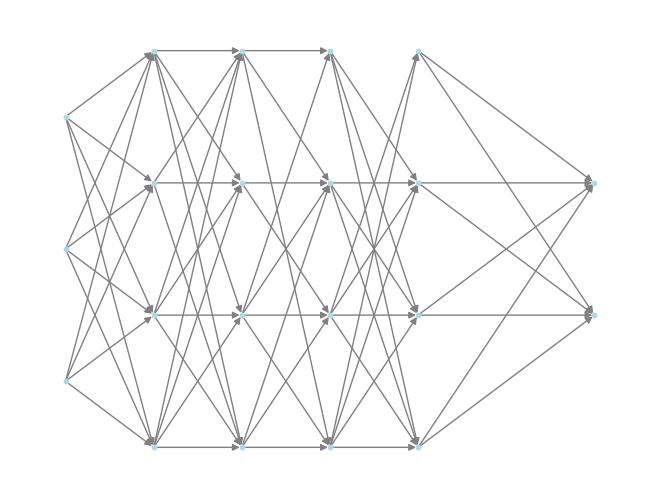

In [355]:
from sparsenn import viz

# Render the optimized architecture 
b = best_model[0]
# b = model
g = viz.gated_connections_graph(b)
fig = viz.render_sparse_nn(g)

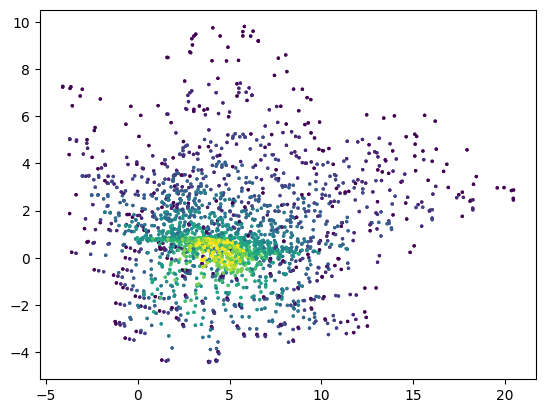

In [340]:
prediction = np.zeros([len(sid), 2])

b = best_model[0]
# b = model
b.eval()
with torch.no_grad():
    prediction[train_idx] = b(x_train).numpy()
    prediction[val_idx] = b(x_valid).numpy()
    prediction[test_idx] = b(x_test).numpy()
plt.scatter(*prediction.T, c=df['p'], s=2, alpha=0.5)

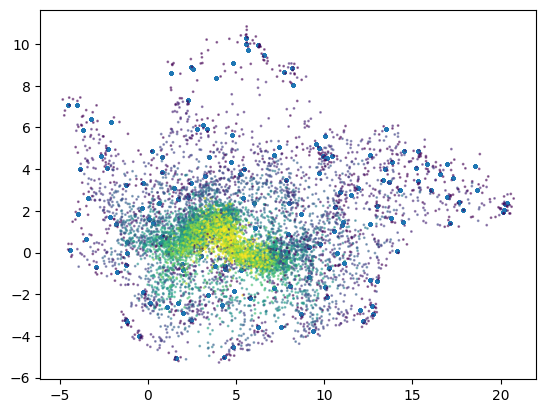

In [341]:
plt.scatter(*x_train[:, 0:2].numpy().T, s=4, alpha=0.5)
plt.scatter(*y_train[:, 0:2].numpy().T, c=x_train[:, 2].numpy(), s=1, alpha=0.5)

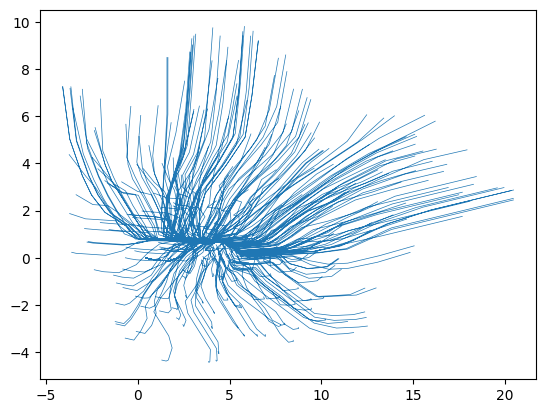

In [342]:
b = best_model[0]
b.eval()
p_pred = np.linspace(0, 1, 11).reshape(-1, 1)
all_out = np.zeros([0, 2])
for z in zp:
    with torch.no_grad():
        x_arr = np.vstack([z]*len(p_pred))
        in_arr = np.hstack([x_arr, p_pred])
        out = b(torch.tensor(in_arr).float())
    all_out = np.vstack([all_out, out, np.nan*np.ones(2)])
plt.plot(*all_out.T, lw=0.5)